In [1]:
from pathlib import Path
import sys
import math
import os

# Configuración del proyecto
PROJECT_ROOT = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()

# Agregar el directorio raíz del proyecto al sys.path para importar módulos personalizados
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch
from sklearn.model_selection import train_test_split
from PIL import Image

# Semilla para reproducibilidad
random.seed(50)
import yaml


from src.utils import get_train_transform, get_val_transform, plot_training_history, show_classification_metrics, show_roc_curve, show_confusion_matrix
from src.models import RadriografiaEfficientNetB3
from src.train import train_model
from src.evaluate import evaluate_model
from src.inference import predict_and_show

In [2]:
CONFIG_PATH = PROJECT_ROOT / "config" / "config.yaml"
# Cargar la configuración del proyecto desde el archivo YAML
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

In [3]:
PROCESSED_PATH = PROJECT_ROOT / config["paths"]["processed_dataset_path"]
MODEL_NAME = config["model"]["name"]

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [8]:
def make_dataset_df(base_dir: str) -> pd.DataFrame:
    data = []
    # Fractured = 1, Non_fractured = 0
    categories = {'non_fractured': 0, 'fractured': 1}

    if base_dir is None:
        print("Error: base_dir es None. Asegúrate de que las carpetas 'fractured' y 'non_fractured' estén en el dataset.")
        return pd.DataFrame(columns=['file_path', 'label'])

    for folder_name, label in categories.items():
        folder_path = os.path.join(base_dir, folder_name)
        if not os.path.exists(folder_path):
            print(f'Carpeta no encontrada: {folder_path}')
            continue

        for file_name in os.scandir(folder_path):
            if file_name.is_file() and file_name.name.lower().endswith(('.png', '.jpg', '.jpeg')):
                data.append((file_name.path, label))

    df = pd.DataFrame(data, columns=['file_path', 'label'])
    return df

df = make_dataset_df(PROCESSED_PATH)
print('Total de imagenes:', df.shape[0])
print('Distribucion de clases:\n', df['label'].value_counts())

Total de imagenes: 4082
Distribucion de clases:
 label
0    3366
1     716
Name: count, dtype: int64


In [9]:
# Split: Train (80%), Val (10%), Test (10%)
if df.empty:
    print('El DataFrame está vacío. No hay imágenes para dividir.')
    train_df = pd.DataFrame(columns=df.columns)
    val_df = pd.DataFrame(columns=df.columns)
    test_df = pd.DataFrame(columns=df.columns)
else:
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f'Train set: {train_df.shape[0]} imagenes')
print(f'Validation set: {val_df.shape[0]} imagenes')
print(f'Test set: {test_df.shape[0]} imagenes')

Train set: 3265 imagenes
Validation set: 408 imagenes
Test set: 409 imagenes


In [10]:
class BoneFractureDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['file_path']
        label = self.dataframe.iloc[idx]['label']

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f'Error leyendo {img_path}: {e}')
            image = Image.new('RGB', (224, 224), 0)

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
best_model_path_tf = PROJECT_ROOT / config["paths"]["model_path_tf"]
save_historial_path_tf = PROJECT_ROOT / config["paths"]["historial_path_tf"]
best_model_path_ft1 = PROJECT_ROOT / config["paths"]["model_path_ft1"]
save_historial_path_ft1 = PROJECT_ROOT / config["paths"]["historial_path_ft1"]
best_model_path_ft2 = PROJECT_ROOT / config["paths"]["model_path_ft2"]
save_historial_path_ft2 = PROJECT_ROOT / config["paths"]["historial_path_ft2"]
best_model_path_ft3 = PROJECT_ROOT / config["paths"]["model_path_ft3"]
save_historial_path_ft3 = PROJECT_ROOT / config["paths"]["historial_path_ft3"]

weight_decays = config["model"]["parameters"]["weight_decay"]
batch_size = config["model"]["parameters"]["batch_size"]
lrs = config["model"]["parameters"]["learning_rate"]
epochs_f = config["model"]["parameters"]["epochs_phases"]
patience = config["model"]["parameters"]["patience"]

In [12]:
train_transform = get_train_transform()

test_val_transform = get_val_transform()

train_dataset = BoneFractureDataset(train_df, transform=train_transform)
val_dataset = BoneFractureDataset(val_df, transform=test_val_transform)
test_dataset = BoneFractureDataset(test_df, transform=test_val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [10]:
model = RadriografiaEfficientNetB3(num_classes=2, model_name=MODEL_NAME, pretrained=True, freeze_backbone=True)
print('Modelo cargado en:', device)
torch.backends.cudnn.benchmark = True

Modelo cargado en: cuda


In [11]:
custom_weights = torch.tensor([0.3, 2.5]).to(device)
print(f'Aplicando pesos de clase manuales para sensibilidad: {custom_weights}')

model.unfreze_backbone(phase_num=0)
model.to(device)
criterion = nn.CrossEntropyLoss(weight=custom_weights)

# Optimizador configurado para las capas de la cabeza inicialmente
parameters_to_optimize = filter(lambda p: p.requires_grad, model.parameters())
optimizer = torch.optim.Adam(parameters_to_optimize, lr=float(lrs[0]), weight_decay=float(weight_decays[0]))

best_valid_recall = 0.0
patience = config["model"]["parameters"]["patience"]
early_stop_counter = 0

Aplicando pesos de clase manuales para sensibilidad: tensor([0.3000, 2.5000], device='cuda:0')


In [13]:
history_tf = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=epochs_f[0],
    save_best_model_path=best_model_path_tf,
    save_historial_path=save_historial_path_tf,
    device=device,
    metric='recall',
    patience=patience
)

Epoch 1/30 [Train]: 100%|██████████| 103/103 [01:06<00:00,  1.55it/s]


Época [1/30] | Train Loss: 0.6435 Acc: 0.3841 Recall: 0.8499 | Val Loss: 0.5991 Acc: 0.5711 Recall: 0.8028
[*] Nuevo mejor modelo guardado (recall: 0.8028) en: /content/checkpoints/radriografia_efficientnet_b3_tf.h5


Epoch 2/30 [Train]: 100%|██████████| 103/103 [00:49<00:00,  2.08it/s]


Época [2/30] | Train Loss: 0.5685 Acc: 0.5041 Recall: 0.8866 | Val Loss: 0.5648 Acc: 0.6691 Recall: 0.8028


Epoch 3/30 [Train]: 100%|██████████| 103/103 [00:47<00:00,  2.19it/s]


...

Época [20/30] | Train Loss: 0.5132 Acc: 0.6398 Recall: 0.8255 | Val Loss: 0.5121 Acc: 0.6887 Recall: 0.7887


Epoch 21/30 [Train]: 100%|██████████| 103/103 [00:47<00:00,  2.16it/s]


Época [21/30] | Train Loss: 0.5225 Acc: 0.6325 Recall: 0.8063 | Val Loss: 0.5082 Acc: 0.6201 Recall: 0.8732


Epoch 22/30 [Train]: 100%|██████████| 103/103 [00:47<00:00,  2.16it/s]


Época [22/30] | Train Loss: 0.5107 Acc: 0.6435 Recall: 0.8220 | Val Loss: 0.5152 Acc: 0.6275 Recall: 0.8451
Early stopping por falta de mejora en recall.


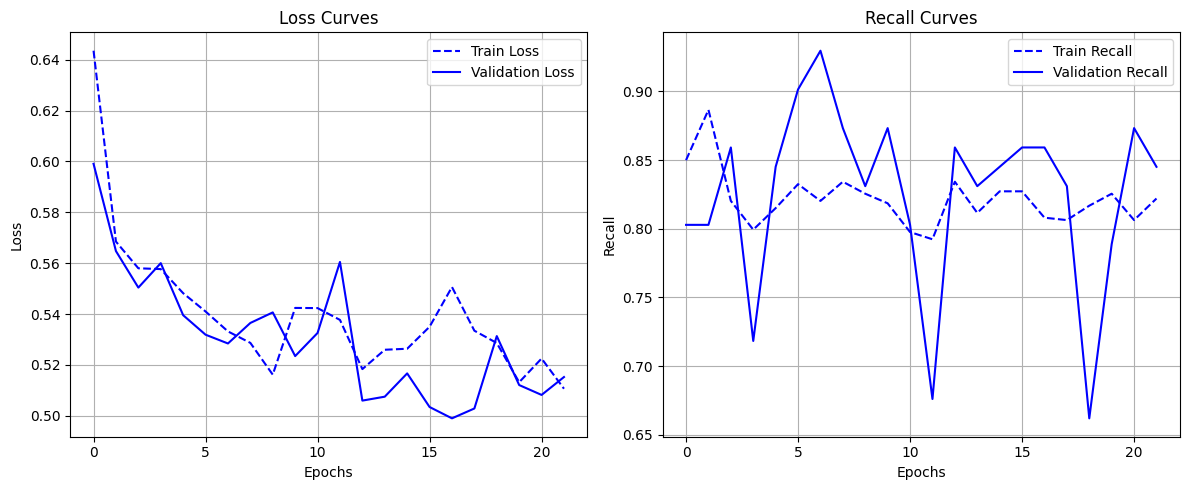

In [14]:
plot_training_history(
    stages=[{'label': 'Stage 1', 'historial': history_tf}],
    metrics=('loss', 'recall'),
    figsize=(12, 5),
    layout='horizontal'
)

Testing: 100%|██████████| 13/13 [00:03<00:00,  3.95it/s]


Loss: 0.5353
Classification Report:
                 precision    recall  f1-score   support

No fractura (0)       0.98      0.50      0.66       337
   Fractura (1)       0.29      0.96      0.45        72

       accuracy                           0.58       409
      macro avg       0.64      0.73      0.55       409
   weighted avg       0.86      0.58      0.62       409



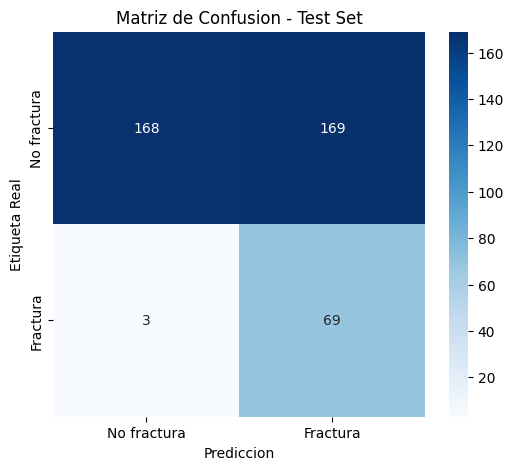

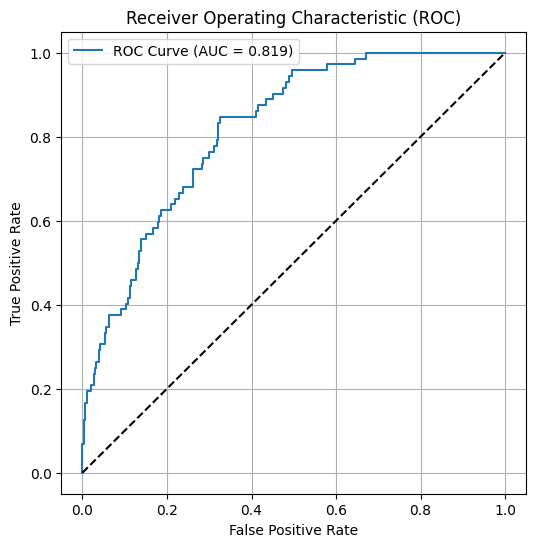

In [16]:
if test_df.empty:
    print("El DataFrame de prueba está vacío. No hay datos para evaluar.")
else:
    resultados_test = evaluate_model(
        model, test_loader, criterion, device,
        model_path=best_model_path_tf
    )

    all_labels = resultados_test['labels']
    all_preds = resultados_test['preds']
    all_probs = resultados_test['probs']

    show_classification_metrics(all_labels, all_preds, target_names=['No fractura (0)', 'Fractura (1)'])
    show_confusion_matrix(all_labels, all_preds, target_names=['No fractura', 'Fractura'])
    show_roc_curve(all_labels, all_probs)

### Fase 2: Fine-Tuning de Capas Superiores
En esta etapa se desbloquean los últimos bloques del backbone para ajustar el modelo a patrones específicos de radiografías óseas, partiendo de los pesos obtenidos en la etapa de Transfer Learning.

In [17]:
# 1. Descongelar las capas finales del backbone
# Desbloqueamos los últimos bloques y la capa de salida
model.unfreze_backbone(phase_num=1)

model.load_state_dict(torch.load(best_model_path_tf, map_location=device))

# 2. Configurar un Learning Rate mucho más bajo para no destruir lo aprendido
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=float(lrs[1]), weight_decay=float(weight_decays[1]))

# 3. Scheduler: Reduce el LR a la mitad si la validación no mejora en 3 épocas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)


print("Capas superiores desbloqueadas. Optimizador y Scheduler configurados.")

Capas superiores desbloqueadas. Optimizador y Scheduler configurados.


In [19]:
history_ft1 = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=int(epochs_f[1]),
    save_best_model_path=best_model_path_ft1,
    save_historial_path=save_historial_path_ft1,
    device=device
)

Epoch 1/20 [Train]: 100%|██████████| 103/103 [01:03<00:00,  1.62it/s]


Época [1/20] | Train Loss: 0.5310 Acc: 0.5939 Recall: 0.8499 | Val Loss: 0.5272 Acc: 0.5931 Recall: 0.8592
[*] Nuevo mejor modelo guardado (acc: 0.5931) en: /content/checkpoints/radriografia_efficientnet_b3_ft1.h5


Epoch 2/20 [Train]: 100%|██████████| 103/103 [00:47<00:00,  2.17it/s]


Época [2/20] | Train Loss: 0.5165 Acc: 0.6294 Recall: 0.8482 | Val Loss: 0.5154 Acc: 0.6201 Recall: 0.8592
[*] Nuevo mejor modelo guardado (acc: 0.6201) en: /content/checkpoints/radriografia_efficientnet_b3_ft1.h5


Epoch 3/20 [Train]: 100%|██████████| 103/103 [00:48<00:00,  2.14it/s]


...

Época [18/20] | Train Loss: 0.4863 Acc: 0.6928 Recall: 0.8394 | Val Loss: 0.4810 Acc: 0.7010 Recall: 0.8169


Epoch 19/20 [Train]: 100%|██████████| 103/103 [00:48<00:00,  2.11it/s]


Época [19/20] | Train Loss: 0.4669 Acc: 0.7047 Recall: 0.8517 | Val Loss: 0.4578 Acc: 0.7083 Recall: 0.8592


Epoch 20/20 [Train]: 100%|██████████| 103/103 [00:48<00:00,  2.12it/s]


Época [20/20] | Train Loss: 0.4679 Acc: 0.6998 Recall: 0.8517 | Val Loss: 0.4600 Acc: 0.6446 Recall: 0.8873


### Evaluación de la Etapa 2
Visualización del progreso y métricas tras el primer ajuste fino de las capas superiores.

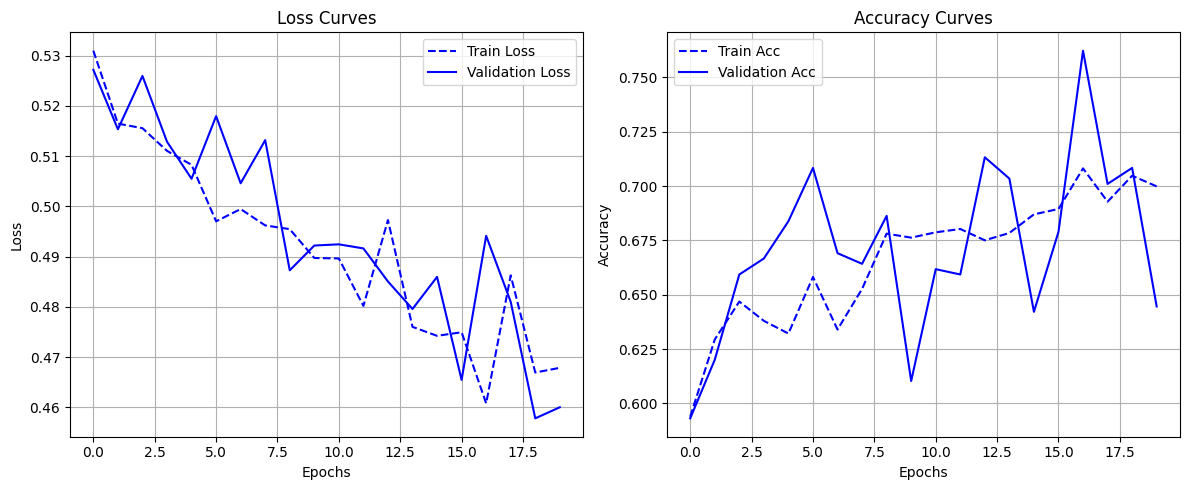

In [20]:
plot_training_history(
    stages=[{'label': 'Stage 2', 'historial': history_ft1}],
    metrics=('loss', 'acc'),
    figsize=(12, 5),
    layout='horizontal'
)

Testing: 100%|██████████| 13/13 [00:03<00:00,  3.91it/s]


Loss: 0.4902
Classification Report:
                 precision    recall  f1-score   support

No fractura (0)       0.94      0.78      0.85       337
   Fractura (1)       0.43      0.76      0.55        72

       accuracy                           0.78       409
      macro avg       0.68      0.77      0.70       409
   weighted avg       0.85      0.78      0.80       409



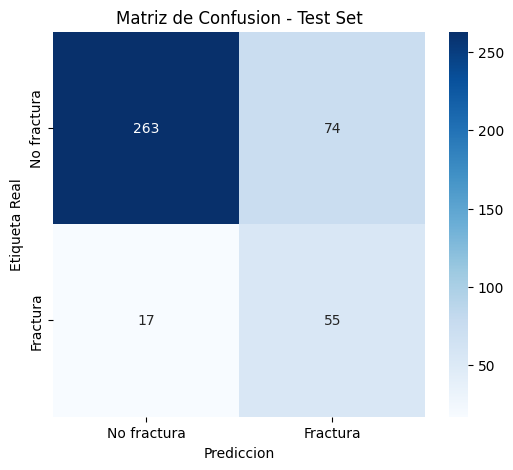

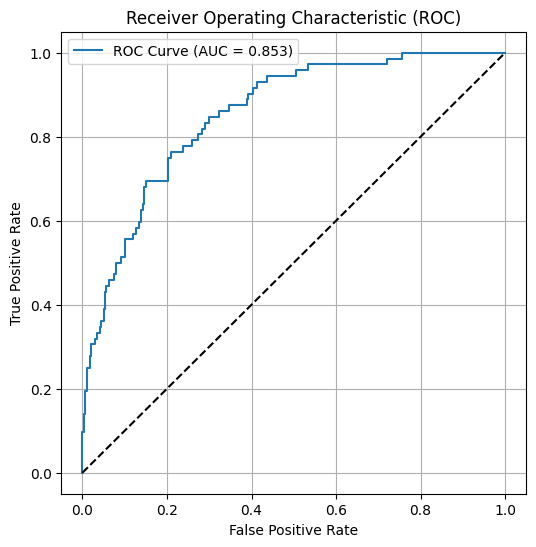

In [25]:
if test_df.empty:
    print("El DataFrame de prueba está vacío. No hay datos para evaluar.")
else:
    resultados_test = evaluate_model(
        model, test_loader, criterion, device,
        model_path=best_model_path_ft1
    )

    all_labels = resultados_test['labels']
    all_preds = resultados_test['preds']
    all_probs = resultados_test['probs']

    show_classification_metrics(all_labels, all_preds, target_names=['No fractura (0)', 'Fractura (1)'])
    show_confusion_matrix(all_labels, all_preds, target_names=['No fractura', 'Fractura'])
    show_roc_curve(all_labels, all_probs)

### Fase 3: Fine-Tuning Intermedio (Bloques 3 y 4)
Descongelación de capas intermedias. Se busca mayor especialización del modelo reduciendo la tasa de aprendizaje para mantener la estabilidad de los pesos previamente ajustados.

In [26]:
torch.cuda.empty_cache()

model.load_state_dict(torch.load(best_model_path_ft1, map_location=device))

model.unfreze_backbone(phase_num=2)

# 3. LR aún más bajo para preservar estabilidad
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=float(lrs[2]), weight_decay=float(weight_decays[2]))

print("Memoria limpia, checkpointing desactivado y capas listas para continuar.")

Memoria limpia, checkpointing desactivado y capas listas para continuar.


In [27]:
history_ft2 = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=int(epochs_f[2]),
    save_best_model_path=best_model_path_ft2,
    save_historial_path=save_historial_path_ft2,
    device=device
)

Epoch 1/15 [Train]: 100%|██████████| 103/103 [01:33<00:00,  1.10it/s]


Época [1/15] | Train Loss: 0.4680 Acc: 0.6953 Recall: 0.8639 | Val Loss: 0.4715 Acc: 0.6667 Recall: 0.8873
[*] Nuevo mejor modelo guardado (acc: 0.6667) en: /content/checkpoints/radriografia_efficientnet_b3_ft2.h5


Epoch 2/15 [Train]: 100%|██████████| 103/103 [00:50<00:00,  2.02it/s]


Época [2/15] | Train Loss: 0.4564 Acc: 0.6998 Recall: 0.8551 | Val Loss: 0.4681 Acc: 0.6618 Recall: 0.8873


Epoch 3/15 [Train]: 100%|██████████| 103/103 [00:49<00:00,  2.09it/s]


...

Época [13/15] | Train Loss: 0.4249 Acc: 0.7274 Recall: 0.8569 | Val Loss: 0.4438 Acc: 0.7279 Recall: 0.8451


Epoch 14/15 [Train]: 100%|██████████| 103/103 [00:50<00:00,  2.02it/s]


Época [14/15] | Train Loss: 0.4024 Acc: 0.7397 Recall: 0.8866 | Val Loss: 0.4514 Acc: 0.7819 Recall: 0.7606
[*] Nuevo mejor modelo guardado (acc: 0.7819) en: /content/checkpoints/radriografia_efficientnet_b3_ft2.h5


Epoch 15/15 [Train]: 100%|██████████| 103/103 [00:51<00:00,  2.02it/s]


Época [15/15] | Train Loss: 0.4279 Acc: 0.7207 Recall: 0.8743 | Val Loss: 0.4345 Acc: 0.7059 Recall: 0.8592


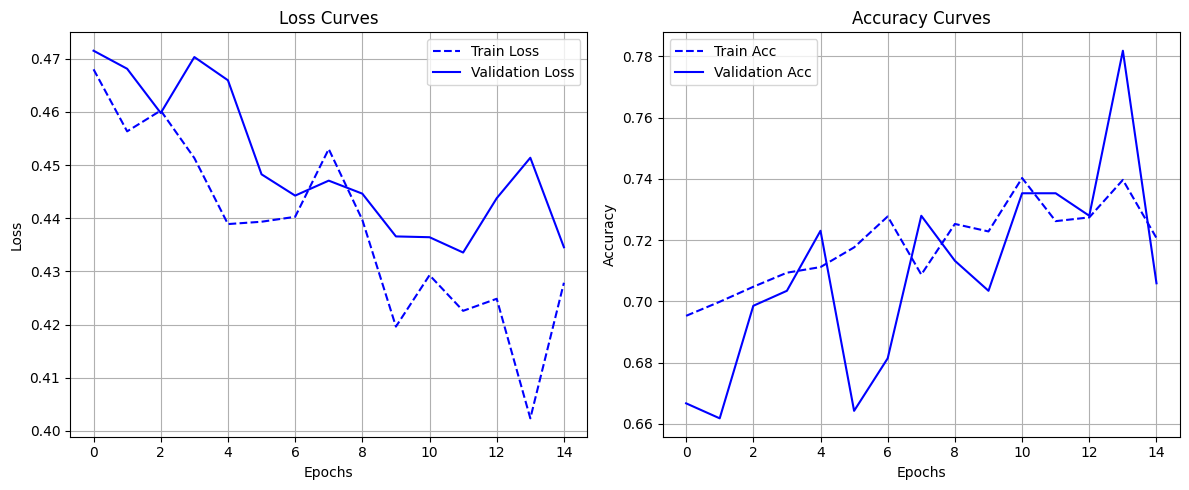

In [28]:
plot_training_history(
    stages=[{'label': 'Stage 3', 'historial': history_ft2}],
    metrics=('loss', 'acc'),
    figsize=(12, 5),
    layout='horizontal'
)

Testing: 100%|██████████| 13/13 [00:03<00:00,  3.80it/s]



Loss: 0.4603
Classification Report:
                 precision    recall  f1-score   support

No fractura (0)       0.93      0.80      0.86       337
   Fractura (1)       0.44      0.74      0.55        72

       accuracy                           0.79       409
      macro avg       0.69      0.77      0.71       409
   weighted avg       0.85      0.79      0.81       409



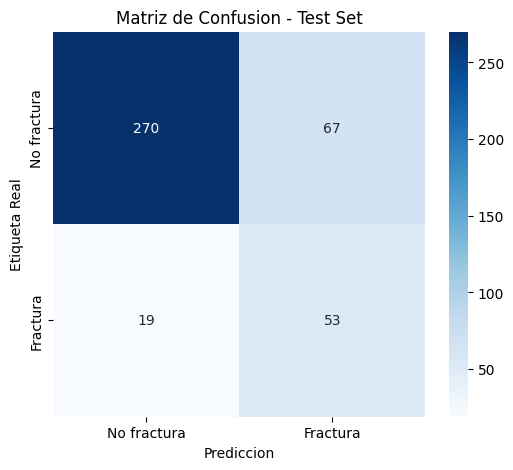

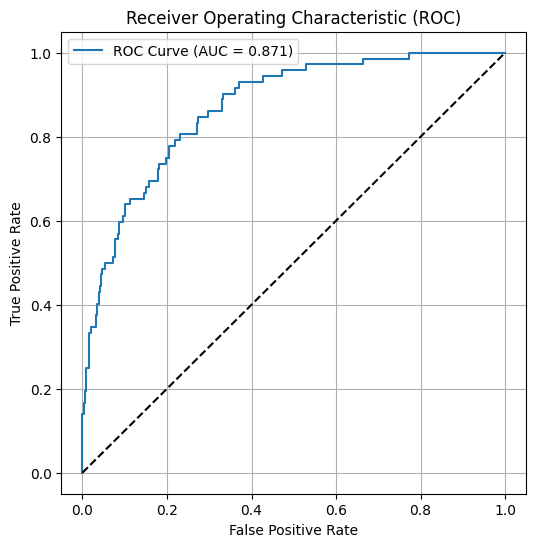

In [34]:
if test_df.empty:
    print("El DataFrame de prueba está vacío. No hay datos para evaluar.")
else:
    resultados_test = evaluate_model(
        model, test_loader, criterion, device,
        model_path=best_model_path_ft2
    )

    all_labels = resultados_test['labels']
    all_preds = resultados_test['preds']
    all_probs = resultados_test['probs']

    show_classification_metrics(all_labels, all_preds, target_names=['No fractura (0)', 'Fractura (1)'])
    show_confusion_matrix(all_labels, all_preds, target_names=['No fractura', 'Fractura'])
    show_roc_curve(all_labels, all_probs)

### Fase 4: Fine-Tuning Profundo (Bloques 1 y 2)
Última etapa de entrenamiento donde se permite el ajuste de las capas iniciales (extractores de características de bajo nivel) para optimizar la precisión global.

In [30]:
torch.cuda.empty_cache()

model.load_state_dict(torch.load(best_model_path_ft2, map_location=device))

model.unfreze_backbone(phase_num=3)

# 3. LR aún más bajo para preservar estabilidad
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=float(lrs[3]), weight_decay=float(weight_decays[3]))

print("Memoria limpia, checkpointing desactivado y capas listas para reintentar.")

Memoria limpia, checkpointing desactivado y capas listas para reintentar.


In [32]:
history_ft3 = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    num_epochs=epochs_f[3],
    save_best_model_path=best_model_path_ft3,
    save_historial_path=save_historial_path_ft3,
    device=device
)

Epoch 1/15 [Train]: 100%|██████████| 103/103 [01:19<00:00,  1.29it/s]


Época [1/15] | Train Loss: 0.4173 Acc: 0.7381 Recall: 0.8709 | Val Loss: 0.4309 Acc: 0.7426 Recall: 0.8310
[*] Nuevo mejor modelo guardado (acc: 0.7426) en: /content/checkpoints/radriografia_efficientnet_b3_ft3.h5


Epoch 2/15 [Train]: 100%|██████████| 103/103 [00:54<00:00,  1.89it/s]


Época [2/15] | Train Loss: 0.4163 Acc: 0.7449 Recall: 0.8551 | Val Loss: 0.4348 Acc: 0.7598 Recall: 0.8310
[*] Nuevo mejor modelo guardado (acc: 0.7598) en: /content/checkpoints/radriografia_efficientnet_b3_ft3.h5


Epoch 3/15 [Train]: 100%|██████████| 103/103 [00:54<00:00,  1.90it/s]


...

Época [13/15] | Train Loss: 0.3790 Acc: 0.7700 Recall: 0.8639 | Val Loss: 0.4023 Acc: 0.7696 Recall: 0.8592


Epoch 14/15 [Train]: 100%|██████████| 103/103 [00:58<00:00,  1.75it/s]


Época [14/15] | Train Loss: 0.3781 Acc: 0.7773 Recall: 0.8883 | Val Loss: 0.3952 Acc: 0.7745 Recall: 0.8732


Epoch 15/15 [Train]: 100%|██████████| 103/103 [00:54<00:00,  1.89it/s]


Época [15/15] | Train Loss: 0.3629 Acc: 0.7917 Recall: 0.8901 | Val Loss: 0.4060 Acc: 0.7819 Recall: 0.8451


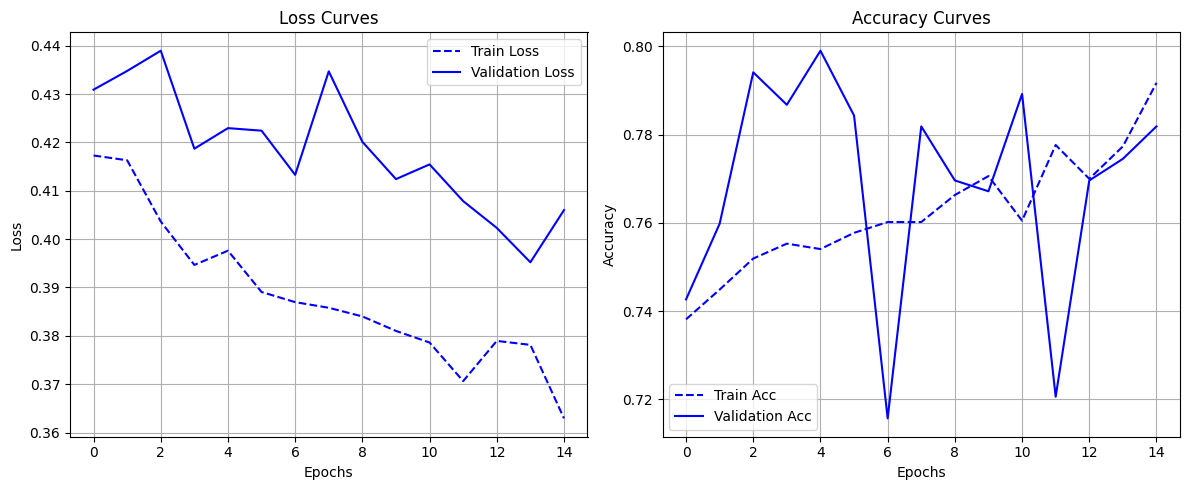

In [35]:
plot_training_history(
    stages=[{'label': 'Stage 4', 'historial': history_ft3}],
    metrics=('loss', 'acc'),
    figsize=(12, 5),
    layout='horizontal'
)

### Visualización Comparativa del Fine-Tuning
Graficamos el progreso de la **Etapa 2 (Bloques Finales)** y la **Etapa 3 (Descongelación Profunda)**.

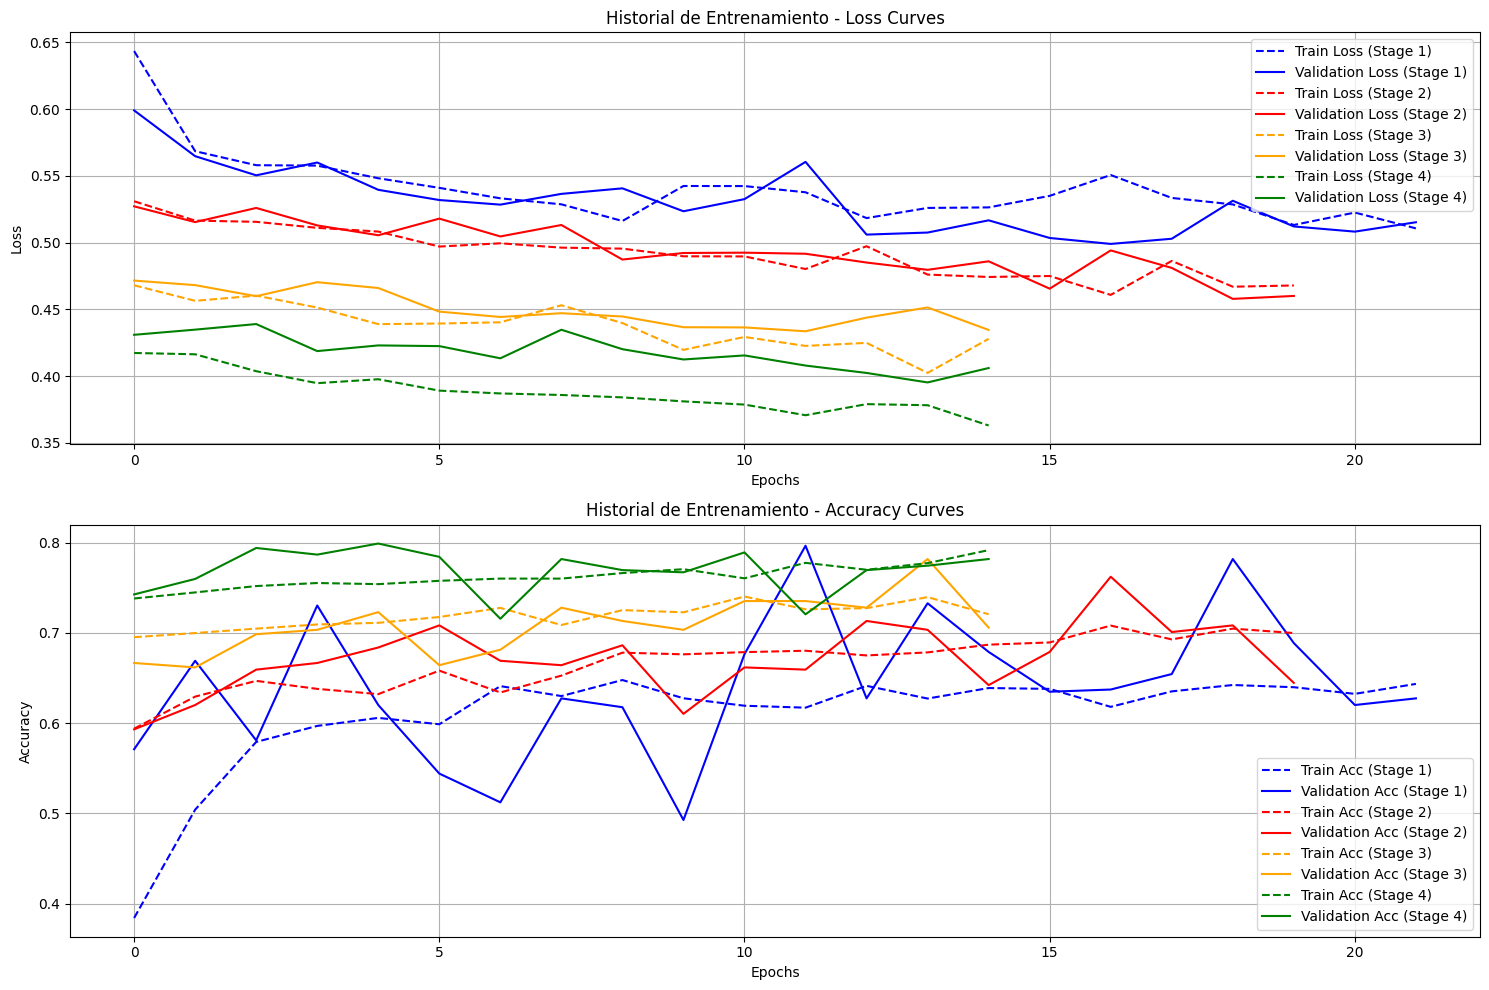

In [36]:
plot_training_history(
    stages=[
        {'label': 'Stage 1', 'historial': history_tf},
        {'label': 'Stage 2', 'historial': history_ft1},
        {'label': 'Stage 3', 'historial': history_ft2},
        {'label': 'Stage 4', 'historial': history_ft3},
    ],
    metrics=('loss', 'acc'),
    layout='vertical'
)

### Pruebas de Inferencia
Carga del mejor modelo guardado durante las fases de fine-tuning para realizar predicciones sobre imágenes individuales.

In [7]:
model = RadriografiaEfficientNetB3(num_classes=2, model_name=MODEL_NAME, pretrained=False, freeze_backbone=False)
model.unfreze_backbone(phase_num=0)
model.to(device)
best_final_model_path = config["paths"]["model_path_ft3"]
model.load_state_dict(torch.load(best_final_model_path, map_location=device))

<All keys matched successfully>

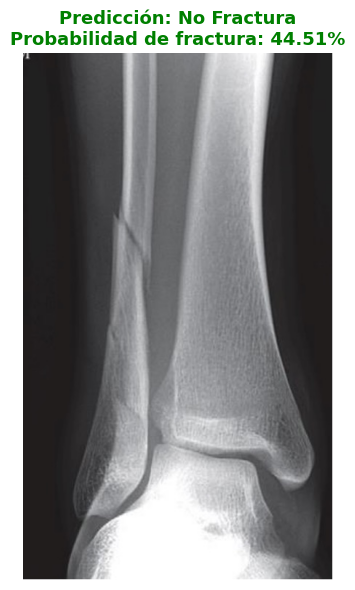

{'class_name': 'No Fractura',
 'class_idx': 0,
 'prob_positive': 0.44513779878616333,
 'probs': array([0.5548622, 0.4451378], dtype=float32)}

In [8]:
path_image_test = './test.jpg'

predict_and_show(model=model, image_path=path_image_test, device=device, transform=get_val_transform())

### Métricas Finales y Matriz de Confusión
Evaluación definitiva sobre el conjunto de test. Análisis del balance entre Precisión y Recall, crítico para la detección de fracturas.

Testing: 100%|██████████| 13/13 [00:03<00:00,  3.40it/s]



Loss: 0.4571
Classification Report:
                 precision    recall  f1-score   support

No fractura (0)       0.93      0.82      0.87       337
   Fractura (1)       0.46      0.72      0.57        72

       accuracy                           0.80       409
      macro avg       0.70      0.77      0.72       409
   weighted avg       0.85      0.80      0.82       409



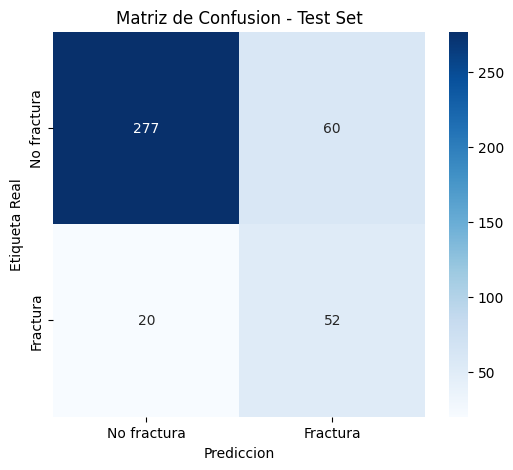

In [48]:
data = evaluate_model(
    model, test_loader, criterion, device,
    model_path=best_final_model_path
)

show_classification_metrics(data['labels'], data['preds'], target_names=['No fractura (0)', 'Fractura (1)'])
show_confusion_matrix(data['labels'], data['preds'], target_names=['No fractura', 'Fractura'])